In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import importlib

logging.basicConfig(level=logging.INFO,
                    format="%(levelname)s | %(name)s | %(message)s")
sns.set_theme(style="whitegrid", font_scale=1.0)

from src.config import cfg
from src.data.loader import load_processed
import src.features.transforms as transforms

# FORCE reload to ensure Jupyter sees the Option C updates
importlib.reload(transforms)

<module 'src.features.transforms' from 'C:\\Users\\CDAC\\Documents\\AI\\weather\\src\\features\\transforms.py'>

In [2]:
# Load the cleaned parquet saved at end of Phase 3
df_clean = load_processed()
print(f"Loaded clean data: {df_clean.shape}")

# Run the full feature pipeline (Upgraded for Multi-Output)
df_features = transforms.build_feature_matrix(
    df_clean.copy(),
    forecast_horizons=[1, 6, 12, 24, 48]
)
print(f"\nFeature matrix: {df_features.shape}")

print(f"\nAll columns ({df_features.shape[1]}):")
for i, col in enumerate(df_features.columns, 1):
    # Visually highlight all 5 of our new target horizons
    marker = "  <-- TARGET" if "temp_c_next_" in col else ""
    print(f"  {i:2}. {col}{marker}")

INFO | src.data.loader | Loading processed data from: C:\Users\CDAC\Documents\AI\weather\data\processed\weather_clean.parquet
INFO | src.data.loader | Loaded processed data: (8785, 21)
INFO | src.features.transforms | Building multi-output feature matrix...
INFO | src.features.transforms | Added cyclical time features: hour, month, dayofyear, is_daytime
INFO | src.features.transforms | Added wind vector components: wind_u, wind_v
INFO | src.features.transforms | Added pressure_tendency
INFO | src.features.transforms | Added 7 lag features: [1, 2, 3, 6, 12, 24, 48]
INFO | src.features.transforms | Added rolling mean+std for windows (hours): [3, 6, 12, 24]
INFO | src.features.transforms | Created multi-forecast targets for horizons: [1, 6, 12, 24, 48]
INFO | src.features.transforms | Dropped 14 redundant/derived columns: ['temp_potential_k', 'temp_logged', 'output_temp', 'wind_direction', 'vapor_pressure_max', 'vapor_pressure_def', 'air_density', 'specific_humidity', 'h2o_concentration',

Loaded clean data: (8785, 21)

Feature matrix: (8658, 37)

All columns (37):
   1. pressure_mbar
   2. temp_c
   3. dew_point_c
   4. humidity_pct
   5. vapor_pressure_act
   6. wind_speed
   7. wind_speed_max
   8. hour_sin
   9. hour_cos
  10. month_sin
  11. month_cos
  12. dayofyear_sin
  13. dayofyear_cos
  14. is_daytime
  15. wind_u
  16. wind_v
  17. pressure_tendency
  18. temp_c_lag_1h
  19. temp_c_lag_2h
  20. temp_c_lag_3h
  21. temp_c_lag_6h
  22. temp_c_lag_12h
  23. temp_c_lag_24h
  24. temp_c_lag_48h
  25. temp_c_roll_mean_3h
  26. temp_c_roll_std_3h
  27. temp_c_roll_mean_6h
  28. temp_c_roll_std_6h
  29. temp_c_roll_mean_12h
  30. temp_c_roll_std_12h
  31. temp_c_roll_mean_24h
  32. temp_c_roll_std_24h
  33. temp_c_next_1h  <-- TARGET
  34. temp_c_next_6h  <-- TARGET
  35. temp_c_next_12h  <-- TARGET
  36. temp_c_next_24h  <-- TARGET
  37. temp_c_next_48h  <-- TARGET


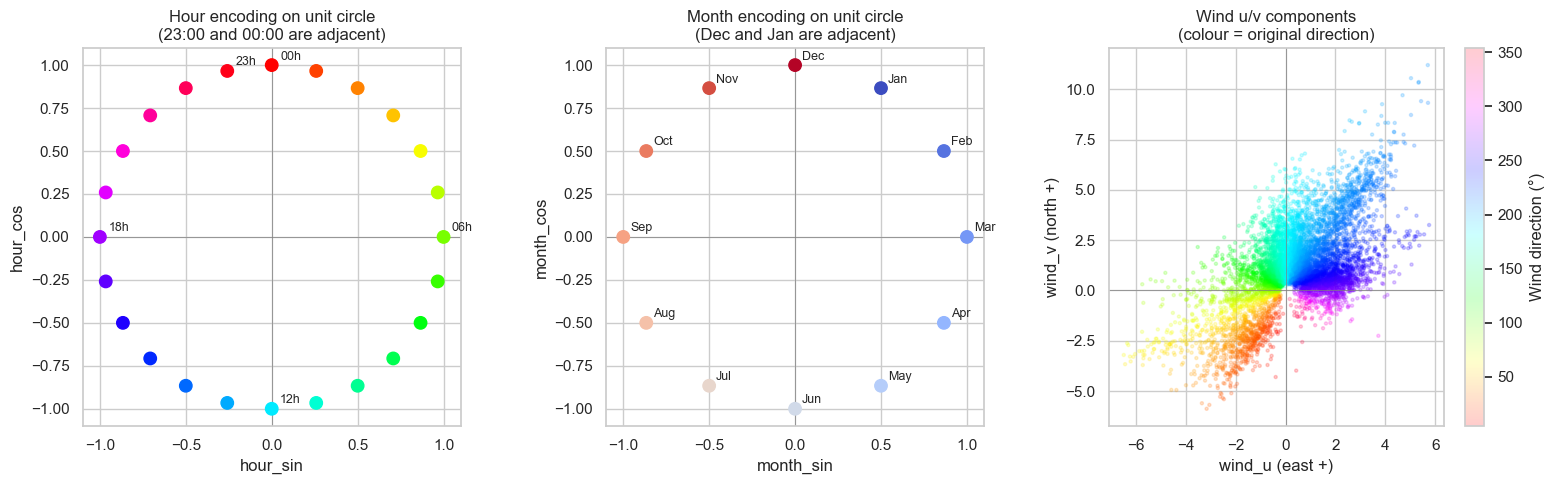

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Hour encoding
hours = np.arange(24)
hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)

axes[0].scatter(hour_sin, hour_cos, c=hours, cmap="hsv", s=80, zorder=5)
for h in [0, 6, 12, 18, 23]:
    s = np.sin(2 * np.pi * h / 24)
    c = np.cos(2 * np.pi * h / 24)
    axes[0].annotate(f"{h:02d}h", (s, c),
                     textcoords="offset points", xytext=(6, 4), fontsize=9)
axes[0].set_title("Hour encoding on unit circle\n(23:00 and 00:00 are adjacent)")
axes[0].set_xlabel("hour_sin")
axes[0].set_ylabel("hour_cos")
axes[0].set_aspect("equal")
axes[0].axhline(0, lw=0.5, color="grey")
axes[0].axvline(0, lw=0.5, color="grey")

# Month encoding
months = np.arange(1, 13)
month_sin = np.sin(2 * np.pi * months / 12)
month_cos = np.cos(2 * np.pi * months / 12)
labels = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

axes[1].scatter(month_sin, month_cos, c=months, cmap="coolwarm", s=80, zorder=5)
for i, (s, c, lab) in enumerate(zip(month_sin, month_cos, labels)):
    axes[1].annotate(lab, (s, c),
                     textcoords="offset points", xytext=(5, 4), fontsize=9)
axes[1].set_title("Month encoding on unit circle\n(Dec and Jan are adjacent)")
axes[1].set_xlabel("month_sin")
axes[1].set_ylabel("month_cos")
axes[1].set_aspect("equal")
axes[1].axhline(0, lw=0.5, color="grey")
axes[1].axvline(0, lw=0.5, color="grey")

# Wind u/v scatter — coloured by original wind direction
scatter = axes[2].scatter(
    df_features["wind_u"], df_features["wind_v"],
    c=df_clean["wind_direction"].reindex(df_features.index),
    cmap="hsv", alpha=0.2, s=5
)
plt.colorbar(scatter, ax=axes[2], label="Wind direction (°)")
axes[2].set_title("Wind u/v components\n(colour = original direction)")
axes[2].set_xlabel("wind_u (east +)")
axes[2].set_ylabel("wind_v (north +)")
axes[2].axhline(0, lw=0.5, color="grey")
axes[2].axvline(0, lw=0.5, color="grey")

plt.tight_layout()
plt.show()

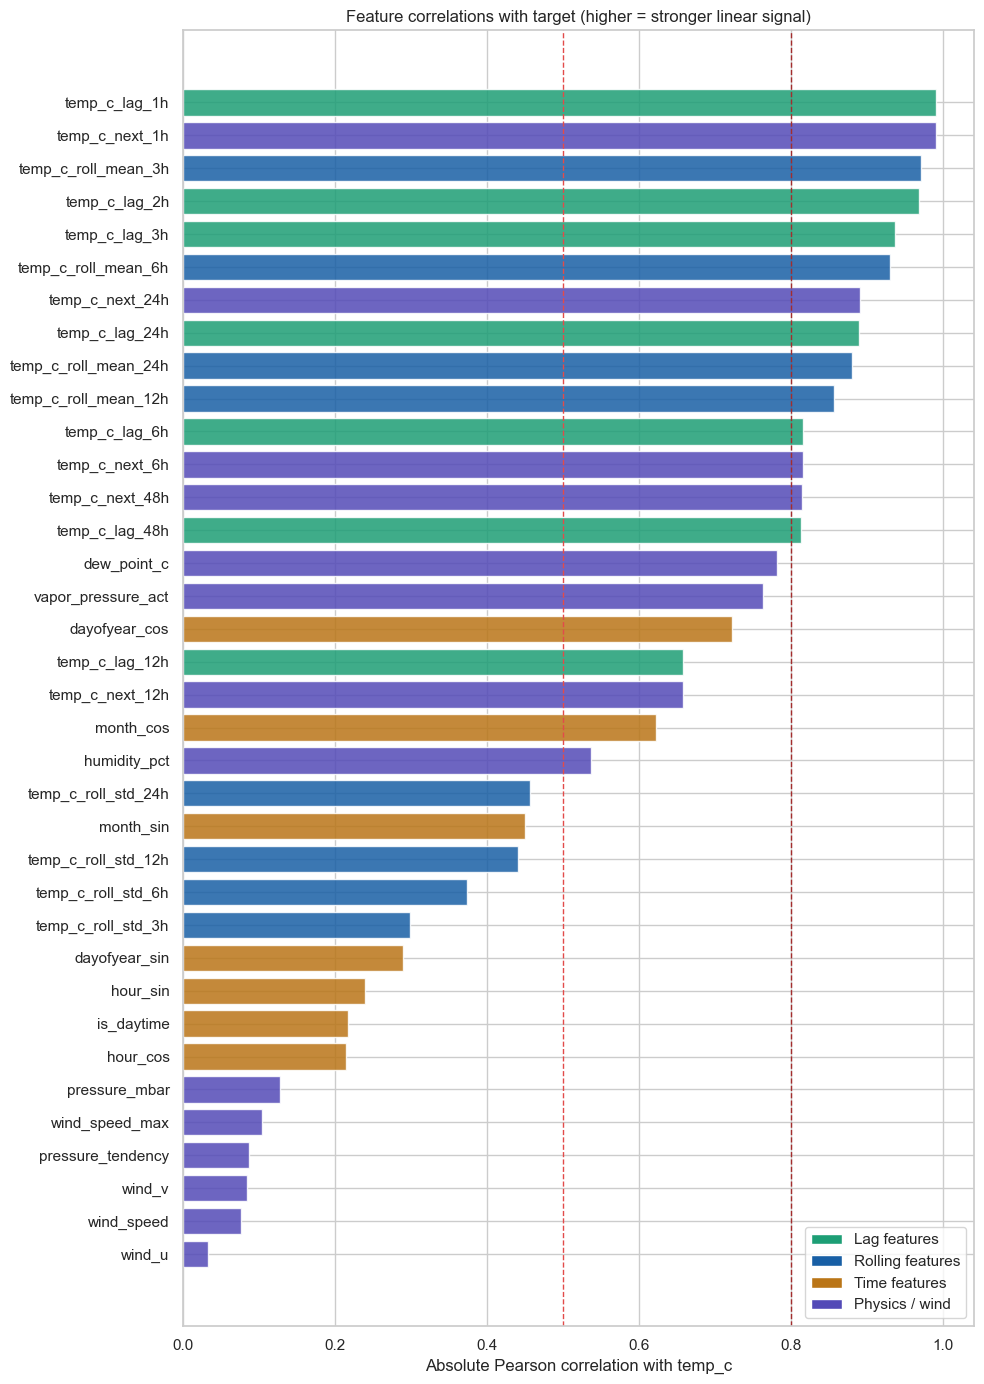

In [4]:
target = "temp_c"
feature_cols = [c for c in df_features.columns if c != target]

corr = (
    df_features[feature_cols]
    .corrwith(df_features[target])
    .abs()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 14))
colors = ["#1D9E75" if "lag" in c
          else "#185FA5" if "roll" in c
          else "#BA7517" if any(t in c for t in ["sin","cos","daytime"])
          else "#534AB7"
          for c in corr.index]

ax.barh(corr.index, corr.values, color=colors, alpha=0.85)
ax.axvline(0.5, color="#E24B4A", lw=1, ls="--", label="r=0.5")
ax.axvline(0.8, color="#A32D2D", lw=1, ls="--", label="r=0.8")
ax.set_xlabel("Absolute Pearson correlation with temp_c")
ax.set_title("Feature correlations with target (higher = stronger linear signal)")
ax.legend()

# Legend for colours
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#1D9E75", label="Lag features"),
    Patch(facecolor="#185FA5", label="Rolling features"),
    Patch(facecolor="#BA7517", label="Time features"),
    Patch(facecolor="#534AB7", label="Physics / wind"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

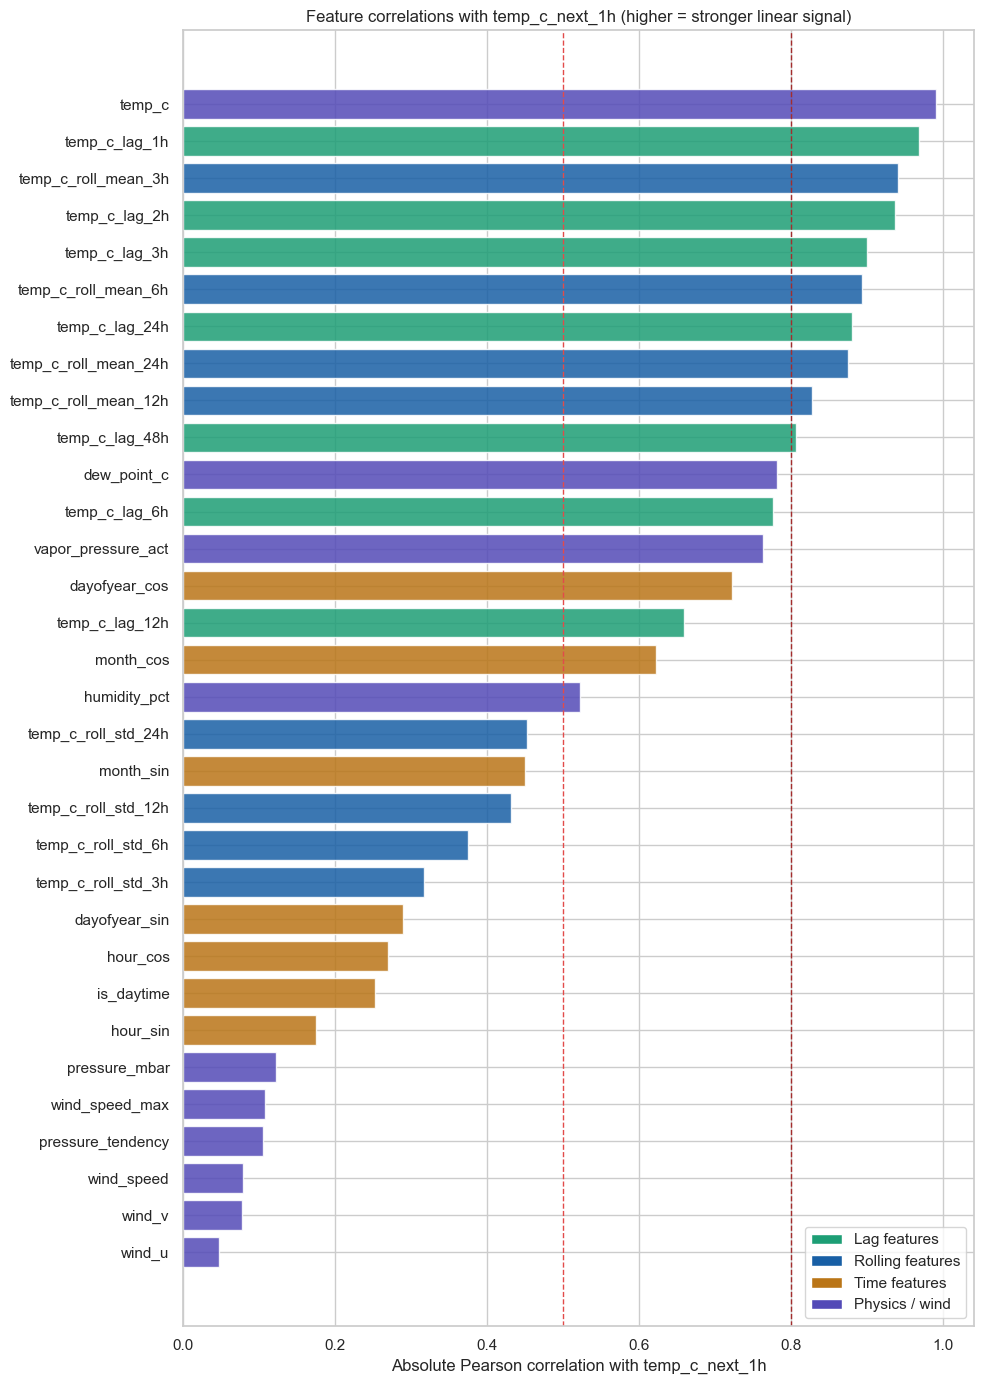

In [5]:
# We will use the 1-hour forecast as our benchmark for the correlation preview
target_preview = "temp_c_next_1h"

# Identify ALL target columns so we cleanly exclude them from the features list
target_cols = [c for c in df_features.columns if c.startswith("temp_c_next_")]
feature_cols = [c for c in df_features.columns if c not in target_cols]

corr = (
    df_features[feature_cols]
    .corrwith(df_features[target_preview])
    .abs()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 14))

colors = ["#1D9E75" if "lag" in c 
          else "#185FA5" if "roll" in c 
          else "#BA7517" if any(t in c for t in ["sin","cos","daytime"]) 
          else "#534AB7" 
          for c in corr.index]

ax.barh(corr.index, corr.values, color=colors, alpha=0.85)

ax.axvline(0.5, color="#E24B4A", lw=1, ls="--", label="r=0.5")
ax.axvline(0.8, color="#A32D2D", lw=1, ls="--", label="r=0.8")

ax.set_xlabel(f"Absolute Pearson correlation with {target_preview}")
ax.set_title(f"Feature correlations with {target_preview} (higher = stronger linear signal)")
ax.legend()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#1D9E75", label="Lag features"),
    Patch(facecolor="#185FA5", label="Rolling features"),
    Patch(facecolor="#BA7517", label="Time features"),
    Patch(facecolor="#534AB7", label="Physics / wind"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
output_path = cfg.features_data_path
output_path.parent.mkdir(parents=True, exist_ok=True)

df_features.to_parquet(output_path)

# Round-trip verification
df_verify = pd.read_parquet(output_path)
assert df_verify.shape == df_features.shape

print(f"✅ Multi-Output Feature matrix saved to: {output_path}")
print(f"   Shape  : {df_features.shape}")
print(f"   Size   : {output_path.stat().st_size / 1024:.1f} KB")

print(f"\nFeature groups:")
lag_cols  = [c for c in df_features.columns if "lag"  in c]
roll_cols = [c for c in df_features.columns if "roll" in c]
time_cols = [c for c in df_features.columns if any(t in c for t in ["sin","cos","daytime"])]
wind_cols = [c for c in df_features.columns if "wind_" in c]
target_cols = [c for c in df_features.columns if "temp_c_next_" in c]

print(f"  Lag features    : {len(lag_cols)}")
print(f"  Rolling features: {len(roll_cols)}")
print(f"  Time features   : {len(time_cols)}")
print(f"  Wind components : {len(wind_cols)}")
print(f"  Target Horizons : {len(target_cols)} {target_cols}")

In [7]:
# ✅ Corrected verification — target lives in df_features, just not in X
MUST_BE_GONE = [
    "wind_direction",
    "par_max", "par", "solar_radiation",
    "air_density", "dew_depression",
    "vapor_pressure_max", "vapor_pressure_def",
    "specific_humidity", "h2o_concentration",
    "output_temp", "temp_potential_k", "temp_logged",
    # ← temp_c_next_1h removed — it belongs in df_features as the target
]

still_present = [c for c in MUST_BE_GONE if c in df_features.columns]

if still_present:
    print(f"\n❌ Still present: {still_present}")
else:
    # Separately confirm target IS present and IS correct
    assert "temp_c_next_1h" in df_features.columns, \
        "❌ Target column missing — create_forecast_target() didn't run"
    assert "temp_c" in df_features.columns, \
        "❌ Current temp_c missing from features"

    df_features.to_parquet(cfg.features_data_path)

    print(f"✅ Clean feature matrix saved: {df_features.shape}")
    print(f"   Rows     : {df_features.shape[0]:,}")
    print(f"   Columns  : {df_features.shape[1]} "
          f"({df_features.shape[1] - 1} features + 1 target)")
    print(f"   Target   : temp_c_next_1h ✅ (present as target)")
    print(f"   temp_c   : {'present ✅' if 'temp_c' in df_features.columns else 'MISSING ❌'}")
    print(f"\nFinal feature set ({df_features.shape[1]} columns):")
    for i, c in enumerate(df_features.columns, 1):
        marker = " ← TARGET" if c == "temp_c_next_1h" else ""
        print(f"  {i:2}. {c}{marker}")

✅ Clean feature matrix saved: (8658, 37)
   Rows     : 8,658
   Columns  : 37 (36 features + 1 target)
   Target   : temp_c_next_1h ✅ (present as target)
   temp_c   : present ✅

Final feature set (37 columns):
   1. pressure_mbar
   2. temp_c
   3. dew_point_c
   4. humidity_pct
   5. vapor_pressure_act
   6. wind_speed
   7. wind_speed_max
   8. hour_sin
   9. hour_cos
  10. month_sin
  11. month_cos
  12. dayofyear_sin
  13. dayofyear_cos
  14. is_daytime
  15. wind_u
  16. wind_v
  17. pressure_tendency
  18. temp_c_lag_1h
  19. temp_c_lag_2h
  20. temp_c_lag_3h
  21. temp_c_lag_6h
  22. temp_c_lag_12h
  23. temp_c_lag_24h
  24. temp_c_lag_48h
  25. temp_c_roll_mean_3h
  26. temp_c_roll_std_3h
  27. temp_c_roll_mean_6h
  28. temp_c_roll_std_6h
  29. temp_c_roll_mean_12h
  30. temp_c_roll_std_12h
  31. temp_c_roll_mean_24h
  32. temp_c_roll_std_24h
  33. temp_c_next_1h ← TARGET
  34. temp_c_next_6h
  35. temp_c_next_12h
  36. temp_c_next_24h
  37. temp_c_next_48h
